In [1]:
# Analysis notebook. Works from the gold-layer tables built in 03_modelling.
# Q1 asks about the view -> cart -> purchase funnel, overall and broken down
# by category and brand.

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

duckdb.sql("SET preserve_insertion_order=false")

result = duckdb.sql("SELECT COUNT(*) AS rows FROM '../data/fact_session_product.parquet'")
result.show()

┌──────────┐
│   rows   │
│  int64   │
├──────────┤
│ 68023553 │
└──────────┘



In [2]:
# Q1a: The funnel, computed strictly.
# Each stage's denominator only counts journeys that actually reached
# the previous stage - so cart-to-purchase counts only products that
# were genuinely carted in that session.

result = duckdb.sql("""
    SELECT
        COUNT(*) AS product_sessions,
        SUM(CASE WHEN viewed THEN 1 ELSE 0 END) AS viewed,
        SUM(CASE WHEN carted THEN 1 ELSE 0 END) AS carted,
        SUM(CASE WHEN carted AND purchased THEN 1 ELSE 0 END) AS carted_and_purchased,
        SUM(CASE WHEN purchased AND NOT carted THEN 1 ELSE 0 END) AS purchased_no_cart,
        ROUND(100.0 * SUM(CASE WHEN carted THEN 1 ELSE 0 END)
              / SUM(CASE WHEN viewed THEN 1 ELSE 0 END), 2) AS view_to_cart_pct,
        ROUND(100.0 * SUM(CASE WHEN carted AND purchased THEN 1 ELSE 0 END)
              / SUM(CASE WHEN carted THEN 1 ELSE 0 END), 2) AS cart_to_purchase_pct
    FROM '../data/fact_session_product.parquet'
""")

result.show()

┌──────────────────┬──────────┬─────────┬──────────────────────┬───────────────────┬──────────────────┬──────────────────────┐
│ product_sessions │  viewed  │ carted  │ carted_and_purchased │ purchased_no_cart │ view_to_cart_pct │ cart_to_purchase_pct │
│      int64       │  int128  │ int128  │        int128        │      int128       │      double      │        double        │
├──────────────────┼──────────┼─────────┼──────────────────────┼───────────────────┼──────────────────┼──────────────────────┤
│         68023553 │ 68007734 │ 2534696 │               996217 │            507589 │             3.73 │                 39.3 │
└──────────────────┴──────────┴─────────┴──────────────────────┴───────────────────┴──────────────────┴──────────────────────┘



In [3]:
# Of the purchases with no cart in the same session, how many had that
# product carted by the same user in an EARLIER session?
# If most did, the "missing" cart isn't missing - it happened on a previous visit.

result = duckdb.sql("""
    WITH no_cart_purchases AS (
        SELECT user_id, product_id, first_event_time
        FROM '../data/fact_session_product.parquet'
        WHERE purchased AND NOT carted
    ),
    earlier_carts AS (
        SELECT user_id, product_id, first_event_time AS cart_time
        FROM '../data/fact_session_product.parquet'
        WHERE carted
    )
    SELECT
        COUNT(*) AS total_no_cart_purchases,
        SUM(CASE WHEN e.user_id IS NOT NULL THEN 1 ELSE 0 END) AS had_earlier_cart
    FROM no_cart_purchases n
    LEFT JOIN earlier_carts e
        ON n.user_id = e.user_id
        AND n.product_id = e.product_id
        AND e.cart_time < n.first_event_time
""")

result.show()

┌─────────────────────────┬──────────────────┐
│ total_no_cart_purchases │ had_earlier_cart │
│          int64          │      int128      │
├─────────────────────────┼──────────────────┤
│                  549166 │            81106 │
└─────────────────────────┴──────────────────┘



In [4]:
# Same question, but using EXISTS so a user who carted the product in
# several earlier sessions doesn't get counted multiple times.

result = duckdb.sql("""
    SELECT
        COUNT(*) AS total_no_cart_purchases,
        SUM(CASE WHEN EXISTS (
            SELECT 1
            FROM '../data/fact_session_product.parquet' e
            WHERE e.user_id = n.user_id
              AND e.product_id = n.product_id
              AND e.carted
              AND e.first_event_time < n.first_event_time
        ) THEN 1 ELSE 0 END) AS had_earlier_cart
    FROM '../data/fact_session_product.parquet' n
    WHERE n.purchased AND NOT n.carted
""")

result.show()

┌─────────────────────────┬──────────────────┐
│ total_no_cart_purchases │ had_earlier_cart │
│          int64          │      int128      │
├─────────────────────────┼──────────────────┤
│                  507589 │            39529 │
└─────────────────────────┴──────────────────┘



In [5]:
# Q1b: Funnel by top-level category.
# Joining to dim_category on category_id (never category_code - remember
# the same code maps to multiple ids, so joining on the text would
# silently merge genuinely different categories).

funnel_by_category = duckdb.sql("""
    SELECT
        c.category_level_1,
        SUM(CASE WHEN f.viewed THEN 1 ELSE 0 END) AS viewed,
        SUM(CASE WHEN f.carted THEN 1 ELSE 0 END) AS carted,
        SUM(CASE WHEN f.carted AND f.purchased THEN 1 ELSE 0 END) AS carted_and_purchased,
        ROUND(100.0 * SUM(CASE WHEN f.carted THEN 1 ELSE 0 END)
              / NULLIF(SUM(CASE WHEN f.viewed THEN 1 ELSE 0 END), 0), 2) AS view_to_cart_pct,
        ROUND(100.0 * SUM(CASE WHEN f.carted AND f.purchased THEN 1 ELSE 0 END)
              / NULLIF(SUM(CASE WHEN f.carted THEN 1 ELSE 0 END), 0), 2) AS cart_to_purchase_pct
    FROM '../data/fact_session_product.parquet' f
    JOIN '../data/dim_category.parquet' c
        ON f.category_id = c.category_id
    GROUP BY c.category_level_1
    HAVING SUM(CASE WHEN f.viewed THEN 1 ELSE 0 END) > 100000
    ORDER BY viewed DESC
""").df()

funnel_by_category

,category_level_1,viewed,carted,carted_and_purchased,view_to_cart_pct,cart_to_purchase_pct
0,electronics,23320892.0,1368164.0,612800.0,5.87,44.79
1,appliances,7504594.0,285809.0,102912.0,3.81,36.01
2,computers,3859500.0,98196.0,33605.0,2.54,34.22
3,apparel,3641446.0,38463.0,10675.0,1.06,27.75
4,unknown_2053013553559896355,3039044.0,178310.0,49200.0,5.87,27.59
5,furniture,2274814.0,30190.0,8823.0,1.33,29.22
6,unknown_2053013563651392361,1628474.0,27329.0,10552.0,1.68,38.61
7,auto,1340920.0,31080.0,11113.0,2.32,35.76
8,construction,1069421.0,29115.0,9560.0,2.72,32.84
9,unknown_2053013556168753601,1031989.0,14960.0,4631.0,1.45,30.96


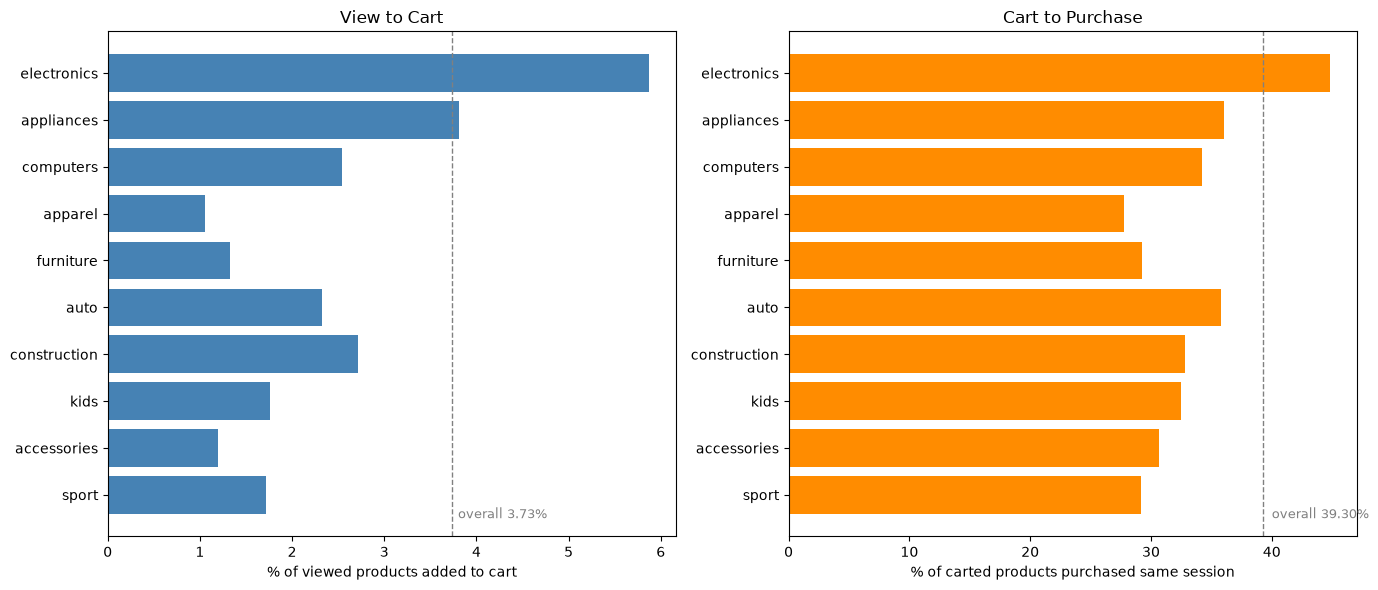

In [6]:
# Chart the named categories only. Filter out the "unknown_" ones since
# they can't be labelled meaningfully on a chart, and note in the write-up
# that this covers roughly two-thirds of activity.

named = funnel_by_category[
    ~funnel_by_category["category_level_1"].str.startswith("unknown_")
].sort_values("viewed", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: view -> cart
axes[0].barh(named["category_level_1"], named["view_to_cart_pct"], color="steelblue")
axes[0].set_xlabel("% of viewed products added to cart")
axes[0].set_title("View to Cart")
axes[0].invert_yaxis()
axes[0].axvline(3.73, color="grey", linestyle="--", linewidth=1)
axes[0].text(3.8, len(named) - 0.5, "overall 3.73%", fontsize=9, color="grey")

# Right: cart -> purchase
axes[1].barh(named["category_level_1"], named["cart_to_purchase_pct"], color="darkorange")
axes[1].set_xlabel("% of carted products purchased same session")
axes[1].set_title("Cart to Purchase")
axes[1].invert_yaxis()
axes[1].axvline(39.30, color="grey", linestyle="--", linewidth=1)
axes[1].text(40, len(named) - 0.5, "overall 39.30%", fontsize=9, color="grey")

plt.tight_layout()
plt.savefig("../docs/funnel_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
from scipy import stats
import numpy as np

# Two-proportion z-test: are appliances and computers genuinely different
# in cart-to-purchase rate, or is the gap explainable by chance?

# appliances: 102,912 purchased out of 285,809 carted
# computers:   33,605 purchased out of  98,196 carted

successes = np.array([102912, 33605])
totals = np.array([285809, 98196])

p1, p2 = successes / totals
pooled = successes.sum() / totals.sum()

# standard error of the difference between two proportions
se = np.sqrt(pooled * (1 - pooled) * (1/totals[0] + 1/totals[1]))
z = (p1 - p2) / se
p_value = 2 * (1 - stats.norm.cdf(abs(z)))

# 95% confidence interval for the difference
se_diff = np.sqrt(p1*(1-p1)/totals[0] + p2*(1-p2)/totals[1])
ci_low = (p1 - p2) - 1.96 * se_diff
ci_high = (p1 - p2) + 1.96 * se_diff

print(f"Appliances: {p1:.4f}  ({successes[0]:,} of {totals[0]:,})")
print(f"Computers:  {p2:.4f}  ({successes[1]:,} of {totals[1]:,})")
print(f"Difference: {p1 - p2:.4f}  ({(p1-p2)*100:.2f} percentage points)")
print(f"95% CI:     [{ci_low*100:.2f}, {ci_high*100:.2f}] percentage points")
print(f"z = {z:.2f}, p = {p_value:.2e}")

Appliances: 0.3601  (102,912 of 285,809)
Computers:  0.3422  (33,605 of 98,196)
Difference: 0.0178  (1.78 percentage points)
95% CI:     [1.44, 2.13] percentage points
z = 10.08, p = 0.00e+00


In [9]:
# Q1c: Funnel by brand.
# dim_product has many rows per product (one per price period), so joining
# to it directly would multiply our counts. Brand doesn't change over time,
# so we take a distinct product->brand lookup first.

funnel_by_brand = duckdb.sql("""
    WITH product_brand AS (
        SELECT DISTINCT product_id, brand
        FROM '../data/dim_product.parquet'
    )
    SELECT
        COALESCE(b.brand, 'unknown') AS brand,
        SUM(CASE WHEN f.viewed THEN 1 ELSE 0 END) AS viewed,
        SUM(CASE WHEN f.carted THEN 1 ELSE 0 END) AS carted,
        SUM(CASE WHEN f.carted AND f.purchased THEN 1 ELSE 0 END) AS carted_and_purchased,
        ROUND(100.0 * SUM(CASE WHEN f.carted THEN 1 ELSE 0 END)
              / NULLIF(SUM(CASE WHEN f.viewed THEN 1 ELSE 0 END), 0), 2) AS view_to_cart_pct,
        ROUND(100.0 * SUM(CASE WHEN f.carted AND f.purchased THEN 1 ELSE 0 END)
              / NULLIF(SUM(CASE WHEN f.carted THEN 1 ELSE 0 END), 0), 2) AS cart_to_purchase_pct
    FROM '../data/fact_session_product.parquet' f
    LEFT JOIN product_brand b ON f.product_id = b.product_id
    GROUP BY COALESCE(b.brand, 'unknown')
    HAVING SUM(CASE WHEN f.viewed THEN 1 ELSE 0 END) > 200000
    ORDER BY viewed DESC
    LIMIT 25
""").df()

funnel_by_brand

,brand,viewed,carted,carted_and_purchased,view_to_cart_pct,cart_to_purchase_pct
0,unknown,16265871.0,380876.0,126988.0,2.34,33.34
1,samsung,7411029.0,547505.0,265449.0,7.39,48.48
2,apple,6285684.0,450606.0,199887.0,7.17,44.36
3,xiaomi,4154531.0,219267.0,80996.0,5.28,36.94
4,huawei,1454954.0,70891.0,33188.0,4.87,46.82
5,lucente,1283846.0,27564.0,10983.0,2.15,39.85
6,lg,907475.0,38791.0,13838.0,4.27,35.67
7,bosch,878304.0,24566.0,8371.0,2.80,34.08
8,respect,794432.0,12334.0,3693.0,1.55,29.94
9,oppo,756294.0,39479.0,19455.0,5.22,49.28


In [13]:
# Verify the distinct product->brand lookup didn't inflate counts.
# Total viewed across ALL brands should equal 68,007,734.

result = duckdb.sql("""
    WITH product_brand AS (
        SELECT DISTINCT product_id, brand FROM '../data/dim_product.parquet'
    )
    SELECT SUM(CASE WHEN f.viewed THEN 1 ELSE 0 END) AS total_viewed
    FROM '../data/fact_session_product.parquet' f
    LEFT JOIN product_brand b ON f.product_id = b.product_id
""")
result.show()

┌──────────────┐
│ total_viewed │
│    int128    │
├──────────────┤
│     73608979 │
└──────────────┘



In [11]:
# How many products have more than one brand value across their price versions?
result = duckdb.sql("""
    SELECT
        COUNT(*) AS products_with_multiple_brands
    FROM (
        SELECT product_id, COUNT(DISTINCT brand) AS brand_count
        FROM '../data/dim_product.parquet'
        GROUP BY product_id
        HAVING COUNT(DISTINCT brand) > 1
    )
""")
result.show()

┌───────────────────────────────┐
│ products_with_multiple_brands │
│             int64             │
├───────────────────────────────┤
│                            62 │
└───────────────────────────────┘



In [12]:
# One brand per product: take the most frequently occurring non-null brand.
# This guarantees exactly one row per product, so the join cannot fan out.

funnel_by_brand = duckdb.sql("""
    WITH product_brand AS (
        SELECT product_id, brand
        FROM (
            SELECT
                product_id,
                brand,
                ROW_NUMBER() OVER (PARTITION BY product_id ORDER BY COUNT(*) DESC) AS rn
            FROM '../data/events_with_sessions.parquet'
            WHERE brand IS NOT NULL
            GROUP BY product_id, brand
        )
        WHERE rn = 1
    )
    SELECT
        COALESCE(b.brand, 'unknown') AS brand,
        SUM(CASE WHEN f.viewed THEN 1 ELSE 0 END) AS viewed,
        SUM(CASE WHEN f.carted THEN 1 ELSE 0 END) AS carted,
        SUM(CASE WHEN f.carted AND f.purchased THEN 1 ELSE 0 END) AS carted_and_purchased,
        ROUND(100.0 * SUM(CASE WHEN f.carted THEN 1 ELSE 0 END)
              / NULLIF(SUM(CASE WHEN f.viewed THEN 1 ELSE 0 END), 0), 2) AS view_to_cart_pct,
        ROUND(100.0 * SUM(CASE WHEN f.carted AND f.purchased THEN 1 ELSE 0 END)
              / NULLIF(SUM(CASE WHEN f.carted THEN 1 ELSE 0 END), 0), 2) AS cart_to_purchase_pct
    FROM '../data/fact_session_product.parquet' f
    LEFT JOIN product_brand b ON f.product_id = b.product_id
    GROUP BY COALESCE(b.brand, 'unknown')
    HAVING SUM(CASE WHEN f.viewed THEN 1 ELSE 0 END) > 200000
    ORDER BY viewed DESC
    LIMIT 25
""").df()

funnel_by_brand

,brand,viewed,carted,carted_and_purchased,view_to_cart_pct,cart_to_purchase_pct
0,unknown,10108655.0,181723.0,56572.0,1.80,31.13
1,samsung,7438134.0,547743.0,265517.0,7.36,48.47
2,apple,6286917.0,450617.0,199889.0,7.17,44.36
3,xiaomi,4162041.0,219549.0,81056.0,5.28,36.92
4,huawei,1454954.0,70891.0,33188.0,4.87,46.82
5,lucente,1289579.0,27654.0,11033.0,2.14,39.90
6,lg,908501.0,38822.0,13845.0,4.27,35.66
7,bosch,879545.0,24591.0,8381.0,2.80,34.08
8,respect,800762.0,12538.0,3762.0,1.57,30.00
9,oppo,756294.0,39479.0,19455.0,5.22,49.28


In [14]:
result = duckdb.sql("""
    WITH product_brand AS (
        SELECT product_id, brand
        FROM (
            SELECT product_id, brand,
                ROW_NUMBER() OVER (PARTITION BY product_id ORDER BY COUNT(*) DESC) AS rn
            FROM '../data/events_with_sessions.parquet'
            WHERE brand IS NOT NULL
            GROUP BY product_id, brand
        ) WHERE rn = 1
    )
    SELECT SUM(CASE WHEN f.viewed THEN 1 ELSE 0 END) AS total_viewed
    FROM '../data/fact_session_product.parquet' f
    LEFT JOIN product_brand b ON f.product_id = b.product_id
""")
result.show()

┌──────────────┐
│ total_viewed │
│    int128    │
├──────────────┤
│     68007734 │
└──────────────┘



In [15]:
# Q2a: What does a typical session look like?
# These distributions are heavily right-skewed - a few enormous sessions
# pull the mean up - so we report percentiles alongside it and will
# explain why the mean alone misleads.

result = duckdb.sql("""
    SELECT
        COUNT(*) AS sessions,
        ROUND(AVG(duration_minutes), 2) AS mean_duration,
        ROUND(MEDIAN(duration_minutes), 2) AS median_duration,
        ROUND(QUANTILE_CONT(duration_minutes, 0.90), 2) AS p90_duration,
        ROUND(QUANTILE_CONT(duration_minutes, 0.99), 2) AS p99_duration,
        ROUND(MAX(duration_minutes), 2) AS max_duration,
        ROUND(AVG(total_events), 2) AS mean_events,
        MEDIAN(total_events) AS median_events,
        QUANTILE_CONT(total_events, 0.90) AS p90_events,
        MAX(total_events) AS max_events
    FROM '../data/fact_session.parquet'
""")

result.show()

┌──────────┬───────────────┬─────────────────┬──────────────┬──────────────┬──────────────┬─────────────┬───────────────┬────────────┬────────────┐
│ sessions │ mean_duration │ median_duration │ p90_duration │ p99_duration │ max_duration │ mean_events │ median_events │ p90_events │ max_events │
│  int64   │    double     │     double      │    double    │    double    │    double    │   double    │    double     │   double   │   int64    │
├──────────┼───────────────┼─────────────────┼──────────────┼──────────────┼──────────────┼─────────────┼───────────────┼────────────┼────────────┤
│ 18776366 │          6.45 │            1.73 │        18.72 │        58.52 │       729.07 │        5.85 │           3.0 │       14.0 │       4128 │
└──────────┴───────────────┴─────────────────┴──────────────┴──────────────┴──────────────┴─────────────┴───────────────┴────────────┴────────────┘



In [16]:
# Are the extreme sessions the same bot-like users we found earlier?
result = duckdb.sql("""
    SELECT
        session_id,
        user_id,
        ROUND(duration_minutes, 1) AS duration_minutes,
        total_events,
        distinct_products,
        items_purchased
    FROM '../data/fact_session.parquet'
    ORDER BY total_events DESC
    LIMIT 10
""")
result.show()

┌──────────────┬───────────┬──────────────────┬──────────────┬───────────────────┬─────────────────┐
│  session_id  │  user_id  │ duration_minutes │ total_events │ distinct_products │ items_purchased │
│   varchar    │   int32   │      double      │    int64     │       int64       │      int64      │
├──────────────┼───────────┼──────────────────┼──────────────┼───────────────────┼─────────────────┤
│ 573277455_1  │ 573277455 │            249.8 │         4128 │              4128 │               0 │
│ 570462872_1  │ 570462872 │            134.5 │         2466 │              2466 │               0 │
│ 577000027_1  │ 577000027 │            105.6 │         1963 │              1963 │               0 │
│ 568142916_24 │ 568142916 │            433.4 │         1707 │              1587 │               0 │
│ 572858723_1  │ 572858723 │             90.6 │         1658 │              1658 │               0 │
│ 542048657_2  │ 542048657 │            447.7 │         1481 │               979 │         

In [17]:
# How many sessions look like catalogue crawlers - many events, every one
# on a different product, nothing purchased?

result = duckdb.sql("""
    SELECT
        COUNT(*) AS crawler_like_sessions,
        SUM(total_events) AS their_events,
        ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM '../data/fact_session.parquet'), 4) AS pct_of_sessions,
        ROUND(100.0 * SUM(total_events) / (SELECT SUM(total_events) FROM '../data/fact_session.parquet'), 2) AS pct_of_events
    FROM '../data/fact_session.parquet'
    WHERE total_events >= 100
      AND total_events = distinct_products
      AND items_purchased = 0
""")
result.show()

┌───────────────────────┬──────────────┬─────────────────┬───────────────┐
│ crawler_like_sessions │ their_events │ pct_of_sessions │ pct_of_events │
│         int64         │    int128    │     double      │    double     │
├───────────────────────┼──────────────┼─────────────────┼───────────────┤
│                    47 │        21955 │          0.0003 │          0.02 │
└───────────────────────┴──────────────┴─────────────────┴───────────────┘



In [18]:
# Q2b: How do purchasing sessions differ from non-purchasing ones?
# Reporting medians rather than means, given the skew we just measured.

result = duckdb.sql("""
    SELECT
        had_purchase,
        COUNT(*) AS sessions,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_of_sessions,
        ROUND(MEDIAN(duration_minutes), 2) AS median_duration,
        MEDIAN(total_events) AS median_events,
        MEDIAN(distinct_products) AS median_products,
        MEDIAN(distinct_categories) AS median_categories,
        ROUND(MEDIAN(view_count), 1) AS median_views,
        ROUND(MEDIAN(cart_count), 1) AS median_carts
    FROM '../data/fact_session.parquet'
    GROUP BY had_purchase
""")

result.show()

┌──────────────┬──────────┬─────────────────┬─────────────────┬───────────────┬─────────────────┬───────────────────┬──────────────┬──────────────┐
│ had_purchase │ sessions │ pct_of_sessions │ median_duration │ median_events │ median_products │ median_categories │ median_views │ median_carts │
│   boolean    │  int64   │     double      │     double      │    double     │     double      │      double       │    double    │    double    │
├──────────────┼──────────┼─────────────────┼─────────────────┼───────────────┼─────────────────┼───────────────────┼──────────────┼──────────────┤
│ false        │ 17485258 │           93.12 │            1.45 │           3.0 │             2.0 │               1.0 │          3.0 │          0.0 │
│ true         │  1291108 │            6.88 │            6.63 │           7.0 │             2.0 │               1.0 │          4.0 │          1.0 │
└──────────────┴──────────┴─────────────────┴─────────────────┴───────────────┴─────────────────┴───────────────

In [19]:
# Q2c: Activity by hour of day, in UTC as stored.
# We'll look at the shape first, then think about what timezone
# the shoppers are actually in.

hourly = duckdb.sql("""
    SELECT
        EXTRACT(HOUR FROM session_start) AS hour_utc,
        COUNT(*) AS sessions,
        SUM(CASE WHEN had_purchase THEN 1 ELSE 0 END) AS purchasing_sessions,
        ROUND(100.0 * SUM(CASE WHEN had_purchase THEN 1 ELSE 0 END) / COUNT(*), 2) AS purchase_rate_pct
    FROM '../data/fact_session.parquet'
    GROUP BY hour_utc
    ORDER BY hour_utc
""").df()

hourly

,hour_utc,sessions,purchasing_sessions,purchase_rate_pct
0,0,135726,4616.0,3.40
1,1,270866,9112.0,3.36
2,2,521782,23250.0,4.46
3,3,743906,49742.0,6.69
4,4,929916,71053.0,7.64
5,5,1029630,82056.0,7.97
6,6,1086571,86838.0,7.99
7,7,1118970,89725.0,8.02
8,8,1146897,95940.0,8.37
9,9,1116613,96478.0,8.64


In [20]:
# Q2d: Demonstrate how the hour-of-day story changes under different
# timezone assumptions. We infer the shoppers' timezone from their own
# sleep trough rather than guessing, then show what conclusions each
# assumption would produce.

hourly_shifted = hourly.copy()
hourly_shifted["hour_utc_plus_3"] = (hourly_shifted["hour_utc"] + 3) % 24
hourly_shifted["hour_utc_plus_5"] = (hourly_shifted["hour_utc"] + 5) % 24

# Where does each assumption place the peak and the trough?
peak_row = hourly_shifted.loc[hourly_shifted["sessions"].idxmax()]
trough_row = hourly_shifted.loc[hourly_shifted["sessions"].idxmin()]
best_conv = hourly_shifted.loc[hourly_shifted["purchase_rate_pct"].idxmax()]

print("PEAK TRAFFIC")
print(f"  UTC:     {int(peak_row['hour_utc']):02d}:00")
print(f"  UTC+3:   {int(peak_row['hour_utc_plus_3']):02d}:00")
print(f"  UTC+5:   {int(peak_row['hour_utc_plus_5']):02d}:00")
print()
print("QUIETEST HOUR (the sleep trough - our anchor for inferring timezone)")
print(f"  UTC:     {int(trough_row['hour_utc']):02d}:00")
print(f"  UTC+3:   {int(trough_row['hour_utc_plus_3']):02d}:00")
print(f"  UTC+5:   {int(trough_row['hour_utc_plus_5']):02d}:00")
print()
print("BEST CONVERTING HOUR")
print(f"  UTC:     {int(best_conv['hour_utc']):02d}:00  ({best_conv['purchase_rate_pct']}%)")
print(f"  UTC+3:   {int(best_conv['hour_utc_plus_3']):02d}:00")
print(f"  UTC+5:   {int(best_conv['hour_utc_plus_5']):02d}:00")

PEAK TRAFFIC
  UTC:     14:00
  UTC+3:   17:00
  UTC+5:   19:00

QUIETEST HOUR (the sleep trough - our anchor for inferring timezone)
  UTC:     23:00
  UTC+3:   02:00
  UTC+5:   04:00

BEST CONVERTING HOUR
  UTC:     09:00  (8.64%)
  UTC+3:   12:00
  UTC+5:   14:00


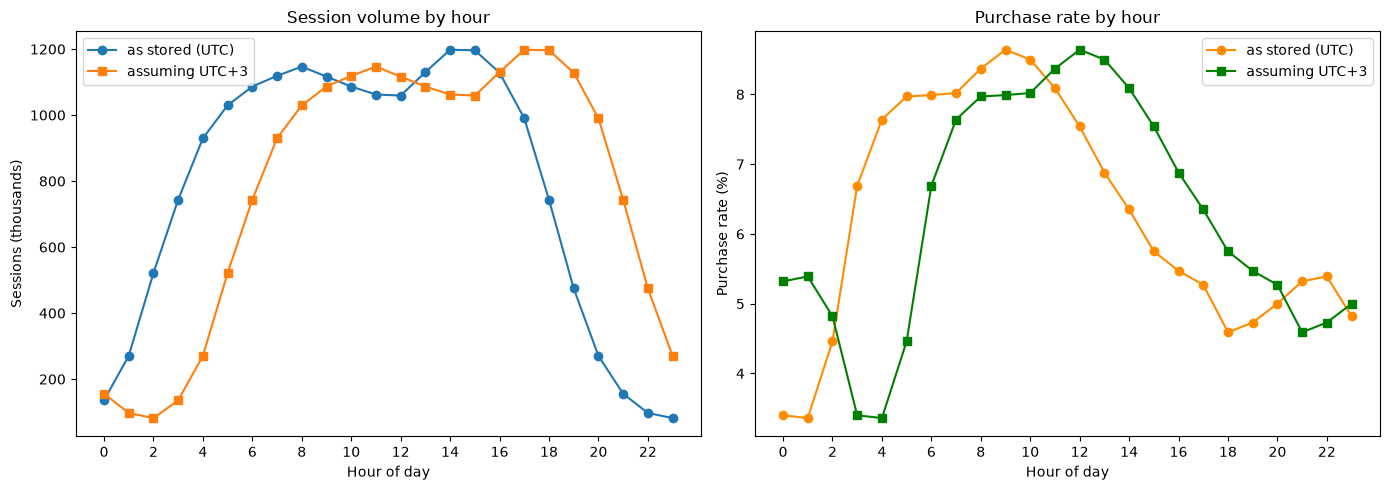

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: sessions by hour, both interpretations
axes[0].plot(hourly["hour_utc"], hourly["sessions"] / 1000, marker="o", label="as stored (UTC)")
shifted = hourly_shifted.sort_values("hour_utc_plus_3")
axes[0].plot(shifted["hour_utc_plus_3"], shifted["sessions"] / 1000, marker="s", label="assuming UTC+3")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Sessions (thousands)")
axes[0].set_title("Session volume by hour")
axes[0].legend()
axes[0].set_xticks(range(0, 24, 2))

# Right: purchase rate by hour
axes[1].plot(hourly["hour_utc"], hourly["purchase_rate_pct"], marker="o", color="darkorange", label="as stored (UTC)")
axes[1].plot(shifted["hour_utc_plus_3"], shifted["purchase_rate_pct"], marker="s", color="green", label="assuming UTC+3")
axes[1].set_xlabel("Hour of day")
axes[1].set_ylabel("Purchase rate (%)")
axes[1].set_title("Purchase rate by hour")
axes[1].legend()
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig("../docs/hourly_timezone_shift.png", dpi=150, bbox_inches="tight")
plt.show()

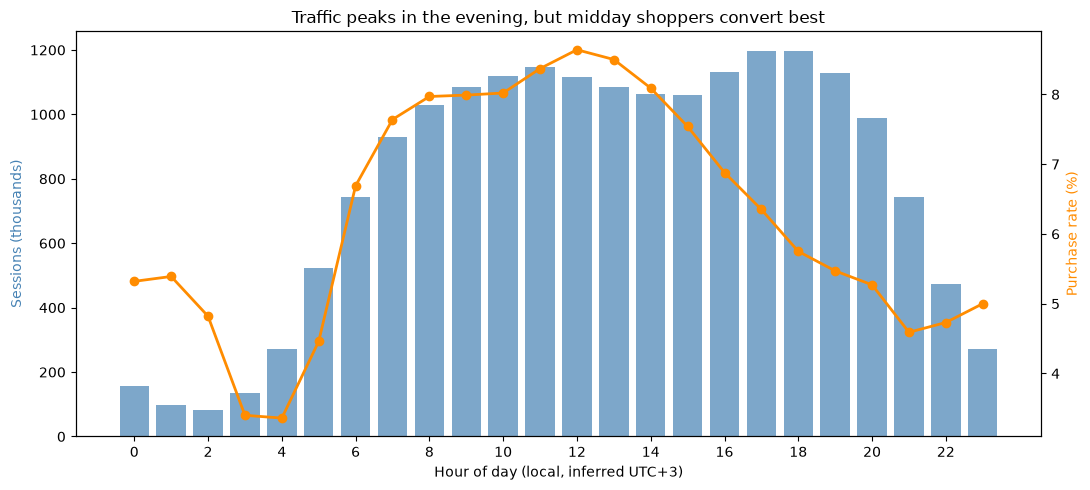

In [22]:
# Q2c: Activity and purchase rate by hour of day, in inferred local time.
# Timestamps are UTC. The quietest hour is 23:00 UTC, which is almost
# certainly the middle of the night for these shoppers, so local time
# appears to be about UTC+3. All hours below are shown as local.

hourly_local = hourly.copy()
hourly_local["hour_local"] = (hourly_local["hour_utc"] + 3) % 24
hourly_local = hourly_local.sort_values("hour_local")

fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.bar(hourly_local["hour_local"], hourly_local["sessions"] / 1000,
        color="steelblue", alpha=0.7, label="Sessions")
ax1.set_xlabel("Hour of day (local, inferred UTC+3)")
ax1.set_ylabel("Sessions (thousands)", color="steelblue")
ax1.set_xticks(range(0, 24, 2))

ax2 = ax1.twinx()
ax2.plot(hourly_local["hour_local"], hourly_local["purchase_rate_pct"],
         color="darkorange", marker="o", linewidth=2, label="Purchase rate")
ax2.set_ylabel("Purchase rate (%)", color="darkorange")

plt.title("Traffic peaks in the evening, but midday shoppers convert best")
plt.tight_layout()
plt.savefig("../docs/hourly_activity.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
# Q3, part 1: How often do prices change, and by how much?
# dim_product has one row per product per price period, so the number of
# rows per product IS the number of price periods it went through.
# One row = price never changed.

result = duckdb.sql("""
    WITH per_product AS (
        SELECT
            product_id,
            COUNT(*) AS price_versions,
            MIN(price) AS min_price,
            MAX(price) AS max_price
        FROM '../data/dim_product.parquet'
        GROUP BY product_id
    )
    SELECT
        COUNT(*) AS total_products,
        SUM(CASE WHEN price_versions = 1 THEN 1 ELSE 0 END) AS never_changed,
        ROUND(100.0 * SUM(CASE WHEN price_versions > 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_that_changed,
        MEDIAN(price_versions) AS median_versions,
        QUANTILE_CONT(price_versions, 0.90) AS p90_versions,
        MAX(price_versions) AS max_versions,
        ROUND(MEDIAN(100.0 * (max_price - min_price) / NULLIF(min_price, 0)), 2) AS median_pct_spread
    FROM per_product
""")

result.show()

┌────────────────┬───────────────┬──────────────────┬─────────────────┬──────────────┬──────────────┬───────────────────┐
│ total_products │ never_changed │ pct_that_changed │ median_versions │ p90_versions │ max_versions │ median_pct_spread │
│     int64      │    int128     │      double      │     double      │    double    │    int64     │       float       │
├────────────────┼───────────────┼──────────────────┼─────────────────┼──────────────┼──────────────┼───────────────────┤
│         206876 │        109107 │            47.26 │             1.0 │          7.0 │         3229 │               0.0 │
└────────────────┴───────────────┴──────────────────┴─────────────────┴──────────────┴──────────────┴───────────────────┘



In [ ]:
# Are the heavily-repriced products the high-traffic ones?
# If repricing is applied selectively to competitive products, we'd expect
# a relationship between version count and view volume.

result = duckdb.sql("""
    WITH versions AS (
        SELECT product_id, COUNT(*) AS price_versions
        FROM '../data/dim_product.parquet'
        GROUP BY product_id
    ),
    traffic AS (
        SELECT product_id, SUM(view_count) AS views
        FROM '../data/fact_session_product.parquet'
        GROUP BY product_id
    )
    SELECT
        CASE
            WHEN v.price_versions = 1 THEN '1 (never changed)'
            WHEN v.price_versions BETWEEN 2 AND 5 THEN '2-5'
            WHEN v.price_versions BETWEEN 6 AND 20 THEN '6-20'
            WHEN v.price_versions BETWEEN 21 AND 100 THEN '21-100'
            ELSE '100+'
        END AS version_band,
        COUNT(*) AS products,
        ROUND(MEDIAN(t.views), 0) AS median_views_per_product
    FROM versions v
    JOIN traffic t ON v.product_id = t.product_id
    GROUP BY version_band
    ORDER BY MIN(v.price_versions)
""")

result.show()

In [24]:
# Are the heavily-repriced products the high-traffic ones?
# If repricing is applied selectively to competitive products, we'd expect
# a relationship between version count and view volume.

result = duckdb.sql("""
    WITH versions AS (
        SELECT product_id, COUNT(*) AS price_versions
        FROM '../data/dim_product.parquet'
        GROUP BY product_id
    ),
    traffic AS (
        SELECT product_id, SUM(view_count) AS views
        FROM '../data/fact_session_product.parquet'
        GROUP BY product_id
    )
    SELECT
        CASE
            WHEN v.price_versions = 1 THEN '1 (never changed)'
            WHEN v.price_versions BETWEEN 2 AND 5 THEN '2-5'
            WHEN v.price_versions BETWEEN 6 AND 20 THEN '6-20'
            WHEN v.price_versions BETWEEN 21 AND 100 THEN '21-100'
            ELSE '100+'
        END AS version_band,
        COUNT(*) AS products,
        ROUND(MEDIAN(t.views), 0) AS median_views_per_product
    FROM versions v
    JOIN traffic t ON v.product_id = t.product_id
    GROUP BY version_band
    ORDER BY MIN(v.price_versions)
""")

result.show()

┌───────────────────┬──────────┬──────────────────────────┐
│   version_band    │ products │ median_views_per_product │
│      varchar      │  int64   │          double          │
├───────────────────┼──────────┼──────────────────────────┤
│ 1 (never changed) │   109107 │                     25.0 │
│ 2-5               │    69853 │                     69.0 │
│ 6-20              │    21433 │                    207.0 │
│ 21-100            │     6300 │                    629.0 │
│ 100+              │      183 │                  64597.0 │
└───────────────────┴──────────┴──────────────────────────┘



In [2]:
# Q3, part 3: Do prices drift or bounce?
# For each product that changed price, compare its NET movement
# (first price vs last price) against its total RANGE (min to max).
# A product that travelled a wide range but ended near where it started
# is bouncing. One that ended far from its start has drifted.
import duckdb
price_pattern = duckdb.sql("""
    WITH product_prices AS (
        SELECT
            product_id,
            COUNT(*) AS versions,
            FIRST(price ORDER BY valid_from) AS first_price,
            LAST(price ORDER BY valid_from) AS last_price,
            MIN(price) AS min_price,
            MAX(price) AS max_price
        FROM '../data/dim_product.parquet'
        GROUP BY product_id
        HAVING COUNT(*) > 1
    )
    SELECT
        COUNT(*) AS products_that_changed,
        ROUND(MEDIAN(100.0 * (last_price - first_price) / NULLIF(first_price, 0)), 2) AS median_net_change_pct,
        ROUND(MEDIAN(100.0 * (max_price - min_price) / NULLIF(min_price, 0)), 2) AS median_range_pct,
        ROUND(MEDIAN(ABS(last_price - first_price) / NULLIF(max_price - min_price, 0)), 3) AS median_net_to_range_ratio,
        SUM(CASE WHEN last_price > first_price THEN 1 ELSE 0 END) AS ended_higher,
        SUM(CASE WHEN last_price < first_price THEN 1 ELSE 0 END) AS ended_lower,
        SUM(CASE WHEN last_price = first_price THEN 1 ELSE 0 END) AS ended_same
    FROM product_prices
""")

price_pattern.show()

┌───────────────────────┬───────────────────────┬──────────────────┬───────────────────────────┬──────────────┬─────────────┬────────────┐
│ products_that_changed │ median_net_change_pct │ median_range_pct │ median_net_to_range_ratio │ ended_higher │ ended_lower │ ended_same │
│         int64         │         float         │      float       │           float           │    int128    │   int128    │   int128   │
├───────────────────────┼───────────────────────┼──────────────────┼───────────────────────────┼──────────────┼─────────────┼────────────┤
│                 97769 │                   0.0 │            13.94 │                       1.0 │        50745 │       36282 │      10742 │
└───────────────────────┴───────────────────────┴──────────────────┴───────────────────────────┴──────────────┴─────────────┴────────────┘



In [3]:
# Restrict to products with enough price versions for "drift vs bounce"
# to be a meaningful question. With only 2 versions the ratio is always
# exactly 1.0 by construction, which tells us nothing.

result = duckdb.sql("""
    WITH product_prices AS (
        SELECT
            product_id,
            COUNT(*) AS versions,
            FIRST(price ORDER BY valid_from) AS first_price,
            LAST(price ORDER BY valid_from) AS last_price,
            MIN(price) AS min_price,
            MAX(price) AS max_price
        FROM '../data/dim_product.parquet'
        GROUP BY product_id
        HAVING COUNT(*) >= 10
    )
    SELECT
        COUNT(*) AS products,
        ROUND(MEDIAN(versions), 0) AS median_versions,
        ROUND(MEDIAN(100.0 * (last_price - first_price) / NULLIF(first_price, 0)), 2) AS median_net_change_pct,
        ROUND(MEDIAN(100.0 * (max_price - min_price) / NULLIF(min_price, 0)), 2) AS median_range_pct,
        ROUND(MEDIAN(ABS(last_price - first_price) / NULLIF(max_price - min_price, 0)), 3) AS median_net_to_range_ratio,
        SUM(CASE WHEN last_price > first_price THEN 1 ELSE 0 END) AS ended_higher,
        SUM(CASE WHEN last_price < first_price THEN 1 ELSE 0 END) AS ended_lower
    FROM product_prices
""")

result.show()

┌──────────┬─────────────────┬───────────────────────┬──────────────────┬───────────────────────────┬──────────────┬─────────────┐
│ products │ median_versions │ median_net_change_pct │ median_range_pct │ median_net_to_range_ratio │ ended_higher │ ended_lower │
│  int64   │     double      │         float         │      float       │           float           │    int128    │   int128    │
├──────────┼─────────────────┼───────────────────────┼──────────────────┼───────────────────────────┼──────────────┼─────────────┤
│    16464 │            17.0 │                 -0.29 │            14.95 │                     0.653 │         5728 │        9070 │
└──────────┴─────────────────┴───────────────────────┴──────────────────┴───────────────────────────┴──────────────┴─────────────┘



In [4]:
# Part 4, step 1: which price changes are isolated enough to study?
# A change is usable only if there's a clear gap before AND after it,
# otherwise the "before" and "after" windows are contaminated by
# neighbouring changes.

result = duckdb.sql("""
    WITH gaps AS (
        SELECT
            product_id,
            price,
            valid_from,
            valid_to,
            DATE_DIFF('hour', valid_from, valid_to) AS hours_this_price_held,
            LAG(DATE_DIFF('hour', valid_from, valid_to))
                OVER (PARTITION BY product_id ORDER BY valid_from) AS hours_previous_price_held
        FROM '../data/dim_product.parquet'
        WHERE valid_to IS NOT NULL
    )
    SELECT
        COUNT(*) AS total_price_periods,
        SUM(CASE WHEN hours_this_price_held >= 24 AND hours_previous_price_held >= 24
                 THEN 1 ELSE 0 END) AS isolated_24h_both_sides,
        SUM(CASE WHEN hours_this_price_held >= 72 AND hours_previous_price_held >= 72
                 THEN 1 ELSE 0 END) AS isolated_72h_both_sides
    FROM gaps
""")

result.show()

┌─────────────────────┬─────────────────────────┬─────────────────────────┐
│ total_price_periods │ isolated_24h_both_sides │ isolated_72h_both_sides │
│        int64        │         int128          │         int128          │
├─────────────────────┼─────────────────────────┼─────────────────────────┤
│              565964 │                  208852 │                   77883 │
└─────────────────────┴─────────────────────────┴─────────────────────────┘



In [5]:
# Part 4, step 2: for isolated price changes, compare demand in the
# 24 hours before vs the 24 hours after.
# We separate increases from decreases - mixing them would cancel out
# any effect.

demand_response = duckdb.sql("""
    WITH isolated_changes AS (
        SELECT
            product_id,
            valid_from AS change_time,
            price AS new_price,
            LAG(price) OVER (PARTITION BY product_id ORDER BY valid_from) AS old_price
        FROM '../data/dim_product.parquet'
        QUALIFY
            DATE_DIFF('hour', valid_from, valid_to) >= 24
            AND LAG(DATE_DIFF('hour', valid_from, valid_to))
                OVER (PARTITION BY product_id ORDER BY valid_from) >= 24
    ),
    with_direction AS (
        SELECT
            *,
            100.0 * (new_price - old_price) / NULLIF(old_price, 0) AS pct_change
        FROM isolated_changes
        WHERE old_price IS NOT NULL
    )
    SELECT
        CASE
            WHEN pct_change <= -10 THEN 'big drop (10%+)'
            WHEN pct_change < 0 THEN 'small drop'
            WHEN pct_change < 10 THEN 'small rise'
            ELSE 'big rise (10%+)'
        END AS change_type,
        COUNT(*) AS num_changes,
        ROUND(MEDIAN(pct_change), 2) AS median_pct_change
    FROM with_direction
    GROUP BY change_type
    ORDER BY median_pct_change
""")

demand_response.show()

┌─────────────────┬─────────────┬───────────────────┐
│   change_type   │ num_changes │ median_pct_change │
│     varchar     │    int64    │       float       │
├─────────────────┼─────────────┼───────────────────┤
│ big drop (10%+) │       25530 │            -19.54 │
│ small drop      │      112772 │             -0.06 │
│ small rise      │       42628 │              1.87 │
│ big rise (10%+) │       27922 │             21.95 │
└─────────────────┴─────────────┴───────────────────┘



In [6]:
# Part 4, step 3: for big price changes only, count views and carts in the
# 24 hours before vs after the change.
# Small changes (median -0.06% / +1.87%) are excluded - they're repricing
# noise, not price moves a shopper would notice.

result = duckdb.sql("""
    WITH isolated_changes AS (
        SELECT
            product_id,
            valid_from AS change_time,
            price AS new_price,
            LAG(price) OVER (PARTITION BY product_id ORDER BY valid_from) AS old_price
        FROM '../data/dim_product.parquet'
        QUALIFY
            DATE_DIFF('hour', valid_from, valid_to) >= 24
            AND LAG(DATE_DIFF('hour', valid_from, valid_to))
                OVER (PARTITION BY product_id ORDER BY valid_from) >= 24
    ),
    big_changes AS (
        SELECT
            product_id,
            change_time,
            100.0 * (new_price - old_price) / NULLIF(old_price, 0) AS pct_change,
            CASE WHEN new_price < old_price THEN 'big drop' ELSE 'big rise' END AS direction
        FROM isolated_changes
        WHERE old_price IS NOT NULL
          AND ABS(100.0 * (new_price - old_price) / NULLIF(old_price, 0)) >= 10
    )
    SELECT
        c.direction,
        COUNT(*) AS changes_measured,
        ROUND(AVG(before.events), 2) AS avg_events_24h_before,
        ROUND(AVG(after.events), 2) AS avg_events_24h_after,
        ROUND(100.0 * (AVG(after.events) - AVG(before.events)) / NULLIF(AVG(before.events), 0), 2) AS pct_demand_change
    FROM big_changes c
    LEFT JOIN LATERAL (
        SELECT COUNT(*) AS events
        FROM '../data/events_with_sessions.parquet' e
        WHERE e.product_id = c.product_id
          AND e.event_time >= c.change_time - INTERVAL 24 HOUR
          AND e.event_time < c.change_time
    ) before ON TRUE
    LEFT JOIN LATERAL (
        SELECT COUNT(*) AS events
        FROM '../data/events_with_sessions.parquet' e
        WHERE e.product_id = c.product_id
          AND e.event_time >= c.change_time
          AND e.event_time < c.change_time + INTERVAL 24 HOUR
    ) after ON TRUE
    GROUP BY c.direction
""")

result.show()

┌───────────┬──────────────────┬───────────────────────┬──────────────────────┬───────────────────┐
│ direction │ changes_measured │ avg_events_24h_before │ avg_events_24h_after │ pct_demand_change │
│  varchar  │      int64       │        double         │        double        │      double       │
├───────────┼──────────────────┼───────────────────────┼──────────────────────┼───────────────────┤
│ big drop  │            25530 │                 14.47 │                19.69 │             36.02 │
│ big rise  │            25337 │                 16.66 │                17.61 │              5.68 │
└───────────┴──────────────────┴───────────────────────┴──────────────────────┴───────────────────┘



In [7]:
# Q4a: Basic repeat-purchase behaviour, before we build the grid.
# How many customers ever order more than once, and how many orders
# do they place?

result = duckdb.sql("""
    SELECT
        COUNT(*) AS purchasing_customers,
        SUM(CASE WHEN total_orders = 1 THEN 1 ELSE 0 END) AS one_order_only,
        SUM(CASE WHEN total_orders > 1 THEN 1 ELSE 0 END) AS repeat_customers,
        ROUND(100.0 * SUM(CASE WHEN total_orders > 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS repeat_rate_pct,
        MEDIAN(total_orders) AS median_orders,
        ROUND(AVG(total_orders), 2) AS mean_orders,
        QUANTILE_CONT(total_orders, 0.90) AS p90_orders,
        MAX(total_orders) AS max_orders
    FROM '../data/dim_user.parquet'
    WHERE has_purchased
""")

result.show()

┌──────────────────────┬────────────────┬──────────────────┬─────────────────┬───────────────┬─────────────┬────────────┬────────────┐
│ purchasing_customers │ one_order_only │ repeat_customers │ repeat_rate_pct │ median_orders │ mean_orders │ p90_orders │ max_orders │
│        int64         │     int128     │      int128      │     double      │    double     │   double    │   double   │   int64    │
├──────────────────────┼────────────────┼──────────────────┼─────────────────┼───────────────┼─────────────┼────────────┼────────────┤
│               697470 │         464424 │           233046 │           33.41 │           1.0 │        1.85 │        3.0 │        191 │
└──────────────────────┴────────────────┴──────────────────┴─────────────────┴───────────────┴─────────────┴────────────┴────────────┘



In [8]:
# Q4b: For customers who ordered more than once, how long between
# their first and second order?

result = duckdb.sql("""
    WITH order_sequence AS (
        SELECT
            user_id,
            order_id,
            MIN(purchase_time) AS order_time,
            ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY MIN(purchase_time)) AS order_number
        FROM '../data/fact_order_item.parquet'
        GROUP BY user_id, order_id
    ),
    first_two AS (
        SELECT
            user_id,
            MAX(CASE WHEN order_number = 1 THEN order_time END) AS first_order,
            MAX(CASE WHEN order_number = 2 THEN order_time END) AS second_order
        FROM order_sequence
        WHERE order_number <= 2
        GROUP BY user_id
    )
    SELECT
        COUNT(*) AS customers_with_second_order,
        ROUND(MEDIAN(DATE_DIFF('hour', first_order, second_order)) / 24.0, 1) AS median_days_to_second,
        ROUND(QUANTILE_CONT(DATE_DIFF('hour', first_order, second_order), 0.25) / 24.0, 1) AS p25_days,
        ROUND(QUANTILE_CONT(DATE_DIFF('hour', first_order, second_order), 0.75) / 24.0, 1) AS p75_days
    FROM first_two
    WHERE second_order IS NOT NULL
""")

result.show()

┌─────────────────────────────┬───────────────────────┬──────────┬──────────┐
│ customers_with_second_order │ median_days_to_second │ p25_days │ p75_days │
│            int64            │        double         │  double  │  double  │
├─────────────────────────────┼───────────────────────┼──────────┼──────────┤
│                      233046 │                   4.3 │      0.9 │     13.8 │
└─────────────────────────────┴───────────────────────┴──────────┴──────────┘



In [9]:
# How many second orders happen suspiciously soon after the first?
# Our order definition splits on 30-min session gaps, so a customer who
# pauses briefly and buys again generates two orders. That may not be
# two genuine shopping trips.

result = duckdb.sql("""
    WITH order_sequence AS (
        SELECT user_id, order_id, MIN(purchase_time) AS order_time,
            ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY MIN(purchase_time)) AS order_number
        FROM '../data/fact_order_item.parquet'
        GROUP BY user_id, order_id
    ),
    first_two AS (
        SELECT user_id,
            MAX(CASE WHEN order_number = 1 THEN order_time END) AS first_order,
            MAX(CASE WHEN order_number = 2 THEN order_time END) AS second_order
        FROM order_sequence WHERE order_number <= 2 GROUP BY user_id
    )
    SELECT
        COUNT(*) AS total,
        SUM(CASE WHEN DATE_DIFF('minute', first_order, second_order) <= 60 THEN 1 ELSE 0 END) AS within_1_hour,
        SUM(CASE WHEN DATE_DIFF('hour', first_order, second_order) <= 24 THEN 1 ELSE 0 END) AS within_24_hours
    FROM first_two WHERE second_order IS NOT NULL
""")
result.show()

┌────────┬───────────────┬─────────────────┐
│ total  │ within_1_hour │ within_24_hours │
│ int64  │    int128     │     int128      │
├────────┼───────────────┼─────────────────┤
│ 233046 │          5758 │           67240 │
└────────┴───────────────┴─────────────────┘



In [10]:
# Q4c: The retention grid.
# Rows = week of first purchase (the cohort).
# Columns = weeks since that first purchase.
# Values = how many of that cohort placed an order in that week.

cohort_grid = duckdb.sql("""
    WITH orders AS (
        SELECT DISTINCT
            f.user_id,
            u.acquisition_cohort_week AS cohort_week,
            DATE_TRUNC('week', f.purchase_date) AS order_week
        FROM '../data/fact_order_item.parquet' f
        JOIN '../data/dim_user.parquet' u ON f.user_id = u.user_id
    )
    SELECT
        cohort_week,
        DATE_DIFF('week', cohort_week, order_week) AS weeks_since_first,
        COUNT(DISTINCT user_id) AS customers
    FROM orders
    GROUP BY cohort_week, weeks_since_first
    ORDER BY cohort_week, weeks_since_first
""").df()

# Pivot into grid shape: cohorts as rows, week offsets as columns
grid = cohort_grid.pivot(index="cohort_week", columns="weeks_since_first", values="customers")
grid

weeks_since_first,0,1,2,3,4,5,6,7,8
cohort_week,,,,,,,,,
2019-09-30,78674.0,15996.0,13754.0,10669.0,8876.0,8916.0,10893.0,6696.0,6010.0
2019-10-07,85245.0,13717.0,9454.0,7595.0,7587.0,10334.0,5744.0,5392.0,NaN
2019-10-14,81004.0,10897.0,7404.0,7302.0,9318.0,5425.0,4676.0,NaN,NaN
2019-10-21,69837.0,7669.0,6213.0,7860.0,4388.0,3878.0,NaN,NaN,NaN
2019-10-28,58851.0,7209.0,7014.0,3907.0,3376.0,NaN,NaN,NaN,NaN
2019-11-04,68252.0,10011.0,5169.0,4158.0,NaN,NaN,NaN,NaN,NaN
2019-11-11,146154.0,10486.0,7683.0,NaN,NaN,NaN,NaN,NaN,NaN
2019-11-18,57783.0,6563.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-11-25,51670.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Convert the grid to retention rates: each cell as a percentage of that
# cohort's week-0 size. We keep the cohort size in the index label so
# the denominator is always visible - a 60% rate from 50 customers is
# noise, and the reader can't tell without the count.

cohort_sizes = grid[0]
retention_pct = grid.div(cohort_sizes, axis=0) * 100

# Relabel the index to include cohort size
retention_pct.index = [
    f"{d.strftime('%Y-%m-%d')}  (n={int(cohort_sizes[d]):,})"
    for d in retention_pct.index
]

retention_pct.round(1)

weeks_since_first,0,1,2,3,4,5,6,7,8
"2019-09-30 (n=78,674)",100.0,20.3,17.5,13.6,11.3,11.3,13.8,8.5,7.6
"2019-10-07 (n=85,245)",100.0,16.1,11.1,8.9,8.9,12.1,6.7,6.3,NaN
"2019-10-14 (n=81,004)",100.0,13.5,9.1,9.0,11.5,6.7,5.8,NaN,NaN
"2019-10-21 (n=69,837)",100.0,11.0,8.9,11.3,6.3,5.6,NaN,NaN,NaN
"2019-10-28 (n=58,851)",100.0,12.2,11.9,6.6,5.7,NaN,NaN,NaN,NaN
"2019-11-04 (n=68,252)",100.0,14.7,7.6,6.1,NaN,NaN,NaN,NaN,NaN
"2019-11-11 (n=146,154)",100.0,7.2,5.3,NaN,NaN,NaN,NaN,NaN,NaN
"2019-11-18 (n=57,783)",100.0,11.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"2019-11-25 (n=51,670)",100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


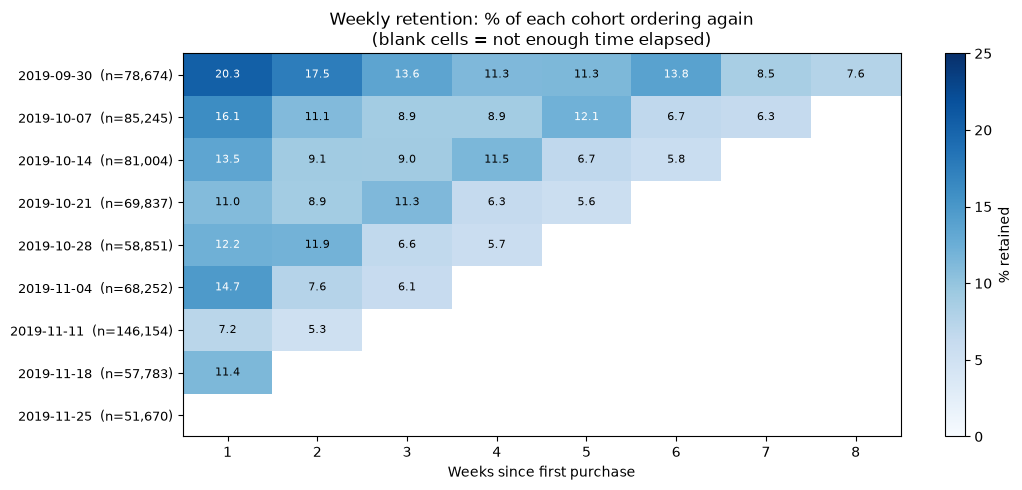

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(11, 5))

# Drop column 0 - it's always 100% by definition and would compress the colour scale
plot_data = retention_pct.drop(columns=[0])

im = ax.imshow(plot_data.values, cmap="Blues", aspect="auto", vmin=0, vmax=25)

ax.set_xticks(range(len(plot_data.columns)))
ax.set_xticklabels(plot_data.columns)
ax.set_yticks(range(len(plot_data.index)))
ax.set_yticklabels(plot_data.index, fontsize=9)
ax.set_xlabel("Weeks since first purchase")
ax.set_title("Weekly retention: % of each cohort ordering again\n(blank cells = not enough time elapsed)")

# Write the value into each cell
for i in range(plot_data.shape[0]):
    for j in range(plot_data.shape[1]):
        val = plot_data.values[i, j]
        if not pd.isna(val):
            ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8,
                    color="white" if val > 12 else "black")

plt.colorbar(im, label="% retained")
plt.tight_layout()
plt.savefig("../docs/cohort_retention.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
# Q5, part 1a: the three RFM inputs, before scoring.
# Snapshot date is 2019-11-30, the last day of data. Recency is measured
# as days from a customer's last purchase to that date.

result = duckdb.sql("""
    SELECT
        COUNT(*) AS customers,
        -- Recency: days since last purchase, as of 2019-11-30
        ROUND(MEDIAN(DATE_DIFF('day', last_purchase_date, DATE '2019-11-30')), 1) AS median_recency_days,
        ROUND(QUANTILE_CONT(DATE_DIFF('day', last_purchase_date, DATE '2019-11-30'), 0.25), 1) AS p25_recency,
        ROUND(QUANTILE_CONT(DATE_DIFF('day', last_purchase_date, DATE '2019-11-30'), 0.75), 1) AS p75_recency,
        -- Frequency
        MEDIAN(total_orders) AS median_frequency,
        QUANTILE_CONT(total_orders, 0.90) AS p90_frequency,
        -- Monetary
        ROUND(MEDIAN(total_revenue), 2) AS median_monetary,
        ROUND(QUANTILE_CONT(total_revenue, 0.90), 2) AS p90_monetary,
        ROUND(MAX(total_revenue), 2) AS max_monetary
    FROM '../data/dim_user.parquet'
    WHERE has_purchased
""")

result.show()

┌───────────┬─────────────────────┬─────────────┬─────────────┬──────────────────┬───────────────┬─────────────────┬──────────────┬──────────────┐
│ customers │ median_recency_days │ p25_recency │ p75_recency │ median_frequency │ p90_frequency │ median_monetary │ p90_monetary │ max_monetary │
│   int64   │       double        │   double    │   double    │      double      │    double     │     double      │    double    │    double    │
├───────────┼─────────────────────┼─────────────┼─────────────┼──────────────────┼───────────────┼─────────────────┼──────────────┼──────────────┤
│    697470 │                20.0 │        12.0 │        39.0 │              1.0 │           3.0 │          249.43 │      1412.88 │     274440.3 │
└───────────┴─────────────────────┴─────────────┴─────────────┴──────────────────┴───────────────┴─────────────────┴──────────────┴──────────────┘



In [16]:
# Who are the extreme spenders? Are they the bot-like accounts we found earlier?
result = duckdb.sql("""
    SELECT
        user_id,
        total_orders,
        total_items_purchased,
        ROUND(total_revenue, 2) AS total_revenue,
        ROUND(total_revenue / NULLIF(total_items_purchased, 0), 2) AS avg_item_price
    FROM '../data/dim_user.parquet'
    WHERE has_purchased
    ORDER BY total_revenue DESC
    LIMIT 10
""")
result.show()

┌───────────┬──────────────┬───────────────────────┬───────────────┬────────────────┐
│  user_id  │ total_orders │ total_items_purchased │ total_revenue │ avg_item_price │
│   int32   │    int64     │         int64         │    double     │     double     │
├───────────┼──────────────┼───────────────────────┼───────────────┼────────────────┤
│ 512386086 │          191 │                   476 │      274440.3 │         576.56 │
│ 519267944 │          117 │                   131 │     188229.97 │        1436.87 │
│ 515384420 │          103 │                   111 │     184301.11 │        1660.37 │
│ 513117637 │           81 │                   139 │     171147.28 │        1231.28 │
│ 534545940 │          118 │                   162 │     165010.24 │        1018.58 │
│ 555394812 │           95 │                   127 │      149463.9 │        1176.88 │
│ 549109608 │          102 │                   280 │     148177.05 │          529.2 │
│ 515715331 │           80 │                   100 │  

In [17]:
# The frequency distribution, for setting manual bin boundaries
result = duckdb.sql("""
    SELECT
        total_orders,
        COUNT(*) AS customers,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_of_customers
    FROM '../data/dim_user.parquet'
    WHERE has_purchased
    GROUP BY total_orders
    ORDER BY total_orders
    LIMIT 10
""")
result.show()

┌──────────────┬───────────┬──────────────────┐
│ total_orders │ customers │ pct_of_customers │
│    int64     │   int64   │      double      │
├──────────────┼───────────┼──────────────────┤
│            1 │    464424 │            66.59 │
│            2 │    125652 │            18.02 │
│            3 │     46840 │             6.72 │
│            4 │     21638 │              3.1 │
│            5 │     11628 │             1.67 │
│            6 │      7247 │             1.04 │
│            7 │      4684 │             0.67 │
│            8 │      3194 │             0.46 │
│            9 │      2328 │             0.33 │
│           10 │      1775 │             0.25 │
└──────────────┴───────────┴──────────────────┘
  10 rows                           3 columns



In [18]:
# Q5, part 1b: RFM scoring.
# Recency and Monetary use quantile bins (both are near-continuous).
# Frequency uses MANUAL bins - the distribution is too concentrated for
# quantiles: 66.6% of customers have exactly 1 order, so the first three
# quantile boundaries would all land on the same value.

rfm = duckdb.sql("""
    WITH base AS (
        SELECT
            user_id,
            DATE_DIFF('day', last_purchase_date, DATE '2019-11-30') AS recency_days,
            total_orders AS frequency,
            total_revenue AS monetary
        FROM '../data/dim_user.parquet'
        WHERE has_purchased
    )
    SELECT
        user_id,
        recency_days,
        frequency,
        monetary,
        -- Recency: lower days = better, so we reverse the score
        6 - NTILE(5) OVER (ORDER BY recency_days) AS r_score,
        -- Frequency: manual bins from the observed distribution
        CASE
            WHEN frequency = 1 THEN 1
            WHEN frequency = 2 THEN 2
            WHEN frequency <= 4 THEN 3
            WHEN frequency <= 9 THEN 4
            ELSE 5
        END AS f_score,
        NTILE(5) OVER (ORDER BY monetary) AS m_score
    FROM base
""").df()

rfm.head()

,user_id,recency_days,frequency,monetary,r_score,f_score,m_score
0,520573734,13,1,0.77,4,1,1
1,513378422,10,1,0.79,4,1,1
2,524830675,7,1,0.87,5,1,1
3,517557126,4,1,0.87,5,1,1
4,513377188,11,1,0.88,4,1,1


In [19]:
# Verify the score distributions. Recency and monetary should be roughly
# 20% each (they're quantile-based). Frequency will be deliberately uneven.

for col in ["r_score", "f_score", "m_score"]:
    print(f"\n{col}:")
    counts = rfm[col].value_counts().sort_index()
    for score, n in counts.items():
        print(f"  {score}: {n:>7,}  ({100*n/len(rfm):>5.1f}%)")


r_score:
  1: 139,494  ( 20.0%)
  2: 139,494  ( 20.0%)
  3: 139,494  ( 20.0%)
  4: 139,494  ( 20.0%)
  5: 139,494  ( 20.0%)

f_score:
  1: 464,424  ( 66.6%)
  2: 125,652  ( 18.0%)
  3:  68,478  (  9.8%)
  4:  29,081  (  4.2%)
  5:   9,835  (  1.4%)

m_score:
  1: 139,494  ( 20.0%)
  2: 139,494  ( 20.0%)
  3: 139,494  ( 20.0%)
  4: 139,494  ( 20.0%)
  5: 139,494  ( 20.0%)


In [20]:
# Assign named segments based on score combinations.
# These definitions are conventional but the boundaries are judgement calls -
# worth stating that in the write-up rather than presenting them as standard.

def segment(row):
    r, f, m = row["r_score"], row["f_score"], row["m_score"]
    
    if r >= 4 and f >= 4:
        return "Champions"
    elif f >= 4 and r <= 2:
        return "At risk (was loyal)"
    elif r >= 4 and f <= 2:
        return "New / recent"
    elif r >= 3 and f >= 3:
        return "Loyal"
    elif r <= 2 and f <= 2:
        return "Lapsed"
    else:
        return "Occasional"

rfm["segment"] = rfm.apply(segment, axis=1)

summary = rfm.groupby("segment").agg(
    customers=("user_id", "count"),
    median_recency=("recency_days", "median"),
    median_frequency=("frequency", "median"),
    median_monetary=("monetary", "median"),
    total_revenue=("monetary", "sum")
).sort_values("total_revenue", ascending=False)

summary["pct_of_customers"] = (100 * summary["customers"] / summary["customers"].sum()).round(1)
summary["pct_of_revenue"] = (100 * summary["total_revenue"] / summary["total_revenue"].sum()).round(1)

summary.round(2)

,customers,median_recency,median_frequency,median_monetary,total_revenue,pct_of_customers,pct_of_revenue
segment,,,,,,,
Champions,25617,4.0,7.0,2344.20,1.069418e+08,3.7,23.7
Lapsed,255295,44.0,1.0,189.97,8.786885e+07,36.6,19.4
New / recent,216735,11.0,1.0,223.94,8.652667e+07,31.1,19.2
Loyal,58084,13.0,3.0,828.83,8.457207e+07,8.3,18.7
Occasional,135478,21.0,1.0,236.24,6.349726e+07,19.4,14.1
At risk (was loyal),6261,36.0,6.0,2106.19,2.240054e+07,0.9,5.0


In [21]:
# Q5, part 2a: daily revenue, orders and new customers across the period.

daily = duckdb.sql("""
    WITH orders AS (
        SELECT
            purchase_date,
            COUNT(DISTINCT order_id) AS orders,
            SUM(event_price) AS revenue,
            COUNT(DISTINCT user_id) AS buyers
        FROM '../data/fact_order_item.parquet'
        GROUP BY purchase_date
    ),
    new_customers AS (
        SELECT first_purchase_date AS purchase_date, COUNT(*) AS new_customers
        FROM '../data/dim_user.parquet'
        WHERE has_purchased
        GROUP BY first_purchase_date
    )
    SELECT
        o.purchase_date,
        DAYNAME(o.purchase_date) AS day_name,
        o.orders,
        ROUND(o.revenue, 0) AS revenue,
        o.buyers,
        COALESCE(n.new_customers, 0) AS new_customers
    FROM orders o
    LEFT JOIN new_customers n ON o.purchase_date = n.purchase_date
    ORDER BY o.purchase_date
""").df()

daily.tail(25)

,purchase_date,day_name,orders,revenue,buyers,new_customers
35,2019-11-05,Tuesday,19965,6534244.0,18287,9861
36,2019-11-06,Wednesday,20024,6639678.0,18456,9873
37,2019-11-07,Thursday,19821,6394915.0,18243,9652
38,2019-11-08,Friday,20521,7011282.0,18845,10060
39,2019-11-09,Saturday,18232,6037470.0,16799,8988
40,2019-11-10,Sunday,18438,6074599.0,17028,9127
41,2019-11-11,Monday,19763,6558877.0,18157,9527
42,2019-11-12,Tuesday,17875,6161119.0,16372,8426
43,2019-11-13,Wednesday,17739,6198524.0,16333,8269
44,2019-11-14,Thursday,17289,6292300.0,15993,8194


In [22]:
# Is 2019-11-15 missing entirely, or only missing purchases?
result = duckdb.sql("""
    SELECT
        CAST(event_time AS DATE) AS event_date,
        event_type,
        COUNT(*) AS events
    FROM '../data/events_with_sessions.parquet'
    WHERE CAST(event_time AS DATE) BETWEEN '2019-11-13' AND '2019-11-18'
    GROUP BY event_date, event_type
    ORDER BY event_date, event_type
""")
result.show()

┌────────────┬────────────┬─────────┐
│ event_date │ event_type │ events  │
│    date    │  varchar   │  int64  │
├────────────┼────────────┼─────────┤
│ 2019-11-13 │ cart       │   69247 │
│ 2019-11-13 │ purchase   │   22548 │
│ 2019-11-13 │ view       │ 1924916 │
│ 2019-11-14 │ cart       │  165541 │
│ 2019-11-14 │ purchase   │   22124 │
│ 2019-11-14 │ view       │ 2877071 │
│ 2019-11-15 │ cart       │  468262 │
│ 2019-11-15 │ view       │ 5737078 │
│ 2019-11-16 │ cart       │  392878 │
│ 2019-11-16 │ purchase   │   68247 │
│ 2019-11-16 │ view       │ 6027799 │
│ 2019-11-17 │ cart       │  411604 │
│ 2019-11-17 │ purchase   │  185195 │
│ 2019-11-17 │ view       │ 5783122 │
│ 2019-11-18 │ cart       │   80682 │
│ 2019-11-18 │ purchase   │   28537 │
│ 2019-11-18 │ view       │ 1909738 │
└────────────┴────────────┴─────────┘
  17 rows                 3 columns



In [23]:
# Q5, part 2b: promotional impact using block comparison.
# Promo block = Thu 14 - Sun 17 Nov. Baseline = the same Thu-Sun weekdays
# from the three preceding weeks.
# Block comparison is used because purchase tracking failed on 15 Nov and
# some of those purchases may have been recorded later - so daily figures
# within the window are unreliable, but the block total should be sound.

impact = duckdb.sql("""
    WITH daily AS (
        SELECT
            purchase_date,
            COUNT(DISTINCT order_id) AS orders,
            SUM(event_price) AS revenue
        FROM '../data/fact_order_item.parquet'
        GROUP BY purchase_date
    ),
    new_cust AS (
        SELECT first_purchase_date AS d, COUNT(*) AS new_customers
        FROM '../data/dim_user.parquet'
        WHERE has_purchased
        GROUP BY first_purchase_date
    ),
    blocks AS (
        SELECT
            CASE
                WHEN d.purchase_date BETWEEN '2019-11-14' AND '2019-11-17' THEN 'promo'
                WHEN d.purchase_date BETWEEN '2019-10-24' AND '2019-10-27' THEN 'baseline_1'
                WHEN d.purchase_date BETWEEN '2019-10-31' AND '2019-11-03' THEN 'baseline_2'
                WHEN d.purchase_date BETWEEN '2019-11-07' AND '2019-11-10' THEN 'baseline_3'
            END AS block,
            d.orders,
            d.revenue,
            COALESCE(n.new_customers, 0) AS new_customers
        FROM daily d
        LEFT JOIN new_cust n ON d.purchase_date = n.d
    )
    SELECT
        block,
        SUM(orders) AS orders,
        ROUND(SUM(revenue), 0) AS revenue,
        SUM(new_customers) AS new_customers
    FROM blocks
    WHERE block IS NOT NULL
    GROUP BY block
    ORDER BY block
""").df()

impact

,block,orders,revenue,new_customers
0,baseline_1,74108.0,25809310.0,38457.0
1,baseline_2,69246.0,23727570.0,34370.0
2,baseline_3,77012.0,25518267.0,37827.0
3,promo,202230.0,78751198.0,119932.0


In [24]:
# Did average order value rise or fall during the promotion?
# Revenue grew faster than orders (215% vs 175%), which suggests larger
# baskets - somewhat counterintuitive if the promotion was discount-driven.

result = duckdb.sql("""
    SELECT
        'baseline (avg of 3 blocks)' AS period,
        ROUND(25018382.0 / 73455, 2) AS avg_order_value
    UNION ALL
    SELECT 'promo (14-17 Nov)', ROUND(78751198.0 / 202230, 2)
""")
result.show()

┌────────────────────────────┬─────────────────┐
│           period           │ avg_order_value │
│          varchar           │     double      │
├────────────────────────────┼─────────────────┤
│ baseline (avg of 3 blocks) │          340.59 │
│ promo (14-17 Nov)          │          389.41 │
└────────────────────────────┴─────────────────┘



In [25]:
# Was the AOV rise driven by more items per order, or by more expensive items?
result = duckdb.sql("""
    SELECT
        CASE WHEN purchase_date BETWEEN '2019-11-14' AND '2019-11-17' THEN 'promo'
             ELSE 'baseline' END AS period,
        COUNT(DISTINCT order_id) AS orders,
        COUNT(*) AS items,
        ROUND(COUNT(*) * 1.0 / COUNT(DISTINCT order_id), 2) AS items_per_order,
        ROUND(AVG(event_price), 2) AS avg_item_price
    FROM '../data/fact_order_item.parquet'
    WHERE purchase_date BETWEEN '2019-11-14' AND '2019-11-17'
       OR purchase_date BETWEEN '2019-10-24' AND '2019-10-27'
       OR purchase_date BETWEEN '2019-10-31' AND '2019-11-03'
       OR purchase_date BETWEEN '2019-11-07' AND '2019-11-10'
    GROUP BY period
""")
result.show()

┌──────────┬────────┬────────┬─────────────────┬────────────────┐
│  period  │ orders │ items  │ items_per_order │ avg_item_price │
│ varchar  │ int64  │ int64  │     double      │     double     │
├──────────┼────────┼────────┼─────────────────┼────────────────┤
│ promo    │ 202230 │ 250855 │            1.24 │         313.93 │
│ baseline │ 220354 │ 251645 │            1.14 │         298.26 │
└──────────┴────────┴────────┴─────────────────┴────────────────┘



In [26]:
# Q5, part 2c: pull-forward test.
# If the promotion borrowed sales from the future, the weeks after should
# fall below baseline. We compare Thu-Sun blocks after the promotion
# against the same three pre-promotion baseline blocks.

pullforward = duckdb.sql("""
    WITH daily AS (
        SELECT
            purchase_date,
            COUNT(DISTINCT order_id) AS orders,
            SUM(event_price) AS revenue
        FROM '../data/fact_order_item.parquet'
        GROUP BY purchase_date
    )
    SELECT
        CASE
            WHEN purchase_date BETWEEN '2019-10-24' AND '2019-10-27' THEN '1. baseline (24-27 Oct)'
            WHEN purchase_date BETWEEN '2019-10-31' AND '2019-11-03' THEN '2. baseline (31 Oct-3 Nov)'
            WHEN purchase_date BETWEEN '2019-11-07' AND '2019-11-10' THEN '3. baseline (7-10 Nov)'
            WHEN purchase_date BETWEEN '2019-11-14' AND '2019-11-17' THEN '4. PROMO (14-17 Nov)'
            WHEN purchase_date BETWEEN '2019-11-21' AND '2019-11-24' THEN '5. after wk1 (21-24 Nov)'
            WHEN purchase_date BETWEEN '2019-11-28' AND '2019-12-01' THEN '6. after wk2 (28-30 Nov)'
        END AS block,
        SUM(orders) AS orders,
        ROUND(SUM(revenue), 0) AS revenue
    FROM daily
    WHERE purchase_date BETWEEN '2019-10-24' AND '2019-11-30'
    GROUP BY block
    HAVING block IS NOT NULL
    ORDER BY block
""").df()

pullforward

,block,orders,revenue
0,1. baseline (24-27 Oct),74108.0,25809310.0
1,2. baseline (31 Oct-3 Nov),69246.0,23727570.0
2,3. baseline (7-10 Nov),77012.0,25518267.0
3,4. PROMO (14-17 Nov),202230.0,78751198.0
4,5. after wk1 (21-24 Nov),73985.0,24069974.0
5,6. after wk2 (28-30 Nov),66492.0,22456747.0
